In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

## 1. 사전 훈련된 모델 로드

In [15]:
# 훈련된 모델 로드
model_path = '../models/mnist_ml_model.pkl'
model = joblib.load(model_path)

print("=" * 60)
print("✓ 모델 로드 완료!")
print("=" * 60)
print(f"모델 경로: {model_path}")
print(f"모델 타입: {type(model).__name__}")
print("=" * 60)

✓ 모델 로드 완료!
모델 경로: ../models/mnist_ml_model.pkl
모델 타입: XGBClassifier


## 2. 테스트 데이터 로드

In [16]:
def load_data(path):
    """.npz 파일을 로드하고 DataFrame으로 변환"""
    data_npz = np.load(path)
    
    # 배열 액세스
    X_images = data_npz['train_images']
    y_labels = data_npz['train_labels']
    
    # 이미지를 28x28에서 784로 평탄화
    images_flat = X_images.reshape(X_images.shape[0], -1)
    
    # DataFrame 생성
    data = pd.DataFrame(images_flat)
    data.insert(0, 'label', y_labels)
    data.index += 1
    
    return data

def split_Xy(data):
    """데이터를 특징과 레이블로 분할"""
    return data.iloc[:, 1:], data.iloc[:, 0]

# 증강된 폰트 데이터셋 로드
aug_data = load_data("../assets/mnist_aug.npz")

print(f"증강된 데이터셋 크기: {aug_data.shape}")
print(f"\n레이블 분포:")
print(aug_data['label'].value_counts().sort_index())

증강된 데이터셋 크기: (150, 785)

레이블 분포:
label
0    15
1    15
2    15
3    15
4    15
5    15
6    15
7    15
8    15
9    15
Name: count, dtype: int64


## 3. 샘플 이미지 시각화

증강된 이미지 샘플:


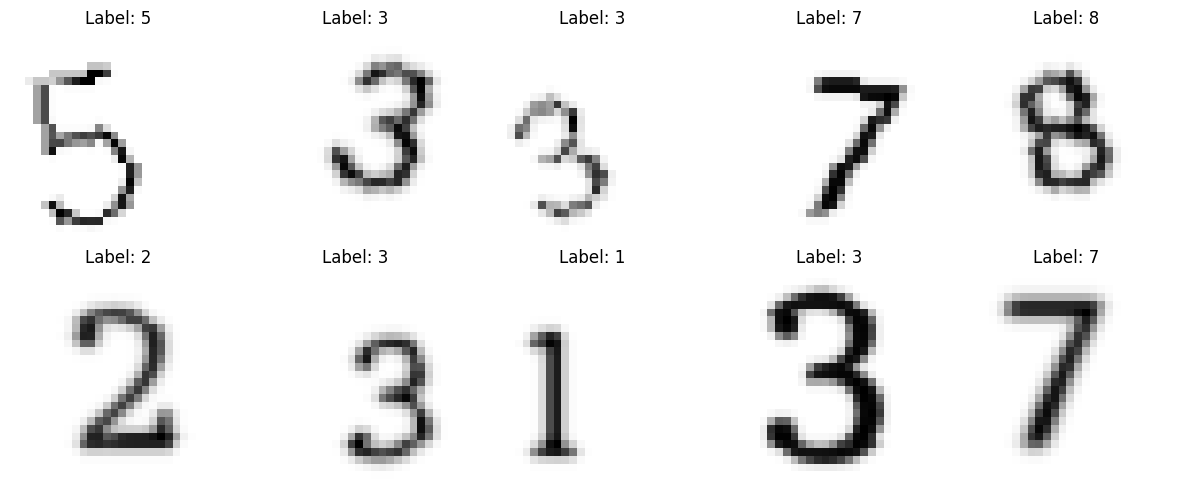

In [17]:
def plot_digit_on_ax(row, ax):
    """특정 축에 숫자를 그리는 헬퍼 함수"""
    image = row[1:].to_numpy().reshape(28, 28)
    ax.imshow(image, cmap="binary")
    ax.axis("off")

# 증강된 데이터셋의 일부 샘플 시각화
print("증강된 이미지 샘플:")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    sample_idx = np.random.randint(0, len(aug_data))
    plot_digit_on_ax(aug_data.iloc[sample_idx], ax)
    ax.set_title(f"Label: {aug_data.iloc[sample_idx]['label']}")

plt.tight_layout()
plt.show()

## 4. 증강 데이터에서 모델 테스트

In [18]:
# 특징과 레이블 분할
X_aug, y_aug = split_Xy(aug_data)

print("=" * 60)
print("증강된 폰트 데이터에서 MNIST 모델 테스트")
print("=" * 60)

# 예측 수행
y_aug_pred = model.predict(X_aug)

# 정확도 계산
aug_accuracy = metrics.accuracy_score(y_aug, y_aug_pred)

print(f"\n📊 테스트 결과:")
print(f"  전체 샘플:          {len(y_aug)}")
print(f"  올바르게 분류됨:    {(y_aug == y_aug_pred).sum()}")
print(f"  잘못 분류됨:        {(y_aug != y_aug_pred).sum()}")
print(f"  정확도:             {aug_accuracy:.4f} ({aug_accuracy*100:.2f}%)")

print("\n" + "=" * 60)

증강된 폰트 데이터에서 MNIST 모델 테스트

📊 테스트 결과:
  전체 샘플:          150
  올바르게 분류됨:    57
  잘못 분류됨:        93
  정확도:             0.3800 (38.00%)



## 5. 혼동 행렬 분석

혼동 행렬 분석


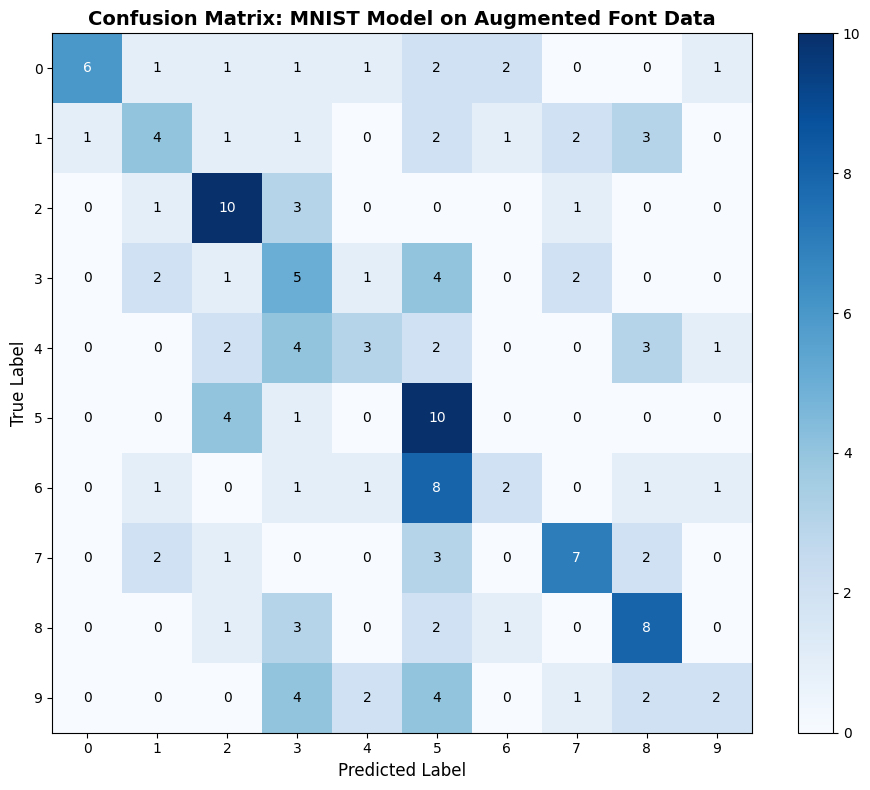


📋 분류 리포트:
              precision    recall  f1-score   support

           0       0.86      0.40      0.55        15
           1       0.36      0.27      0.31        15
           2       0.48      0.67      0.56        15
           3       0.22      0.33      0.26        15
           4       0.38      0.20      0.26        15
           5       0.27      0.67      0.38        15
           6       0.33      0.13      0.19        15
           7       0.54      0.47      0.50        15
           8       0.42      0.53      0.47        15
           9       0.40      0.13      0.20        15

    accuracy                           0.38       150
   macro avg       0.43      0.38      0.37       150
weighted avg       0.43      0.38      0.37       150



In [19]:
print("=" * 60)
print("혼동 행렬 분석")
print("=" * 60)

# 혼동 행렬
cm = confusion_matrix(y_aug, y_aug_pred)

# 혼동 행렬 플롯
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')

# 레이블
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix: MNIST Model on Augmented Font Data', fontsize=14, fontweight='bold')

# 텍스트 주석 추가
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\n📋 분류 리포트:")
print(classification_report(y_aug, y_aug_pred, target_names=[str(i) for i in range(10)]))

## 6. 잘못 분류된 샘플 분석

가장 혼동된 예측

전체 잘못 분류됨: 93 / 150 (62.00%)


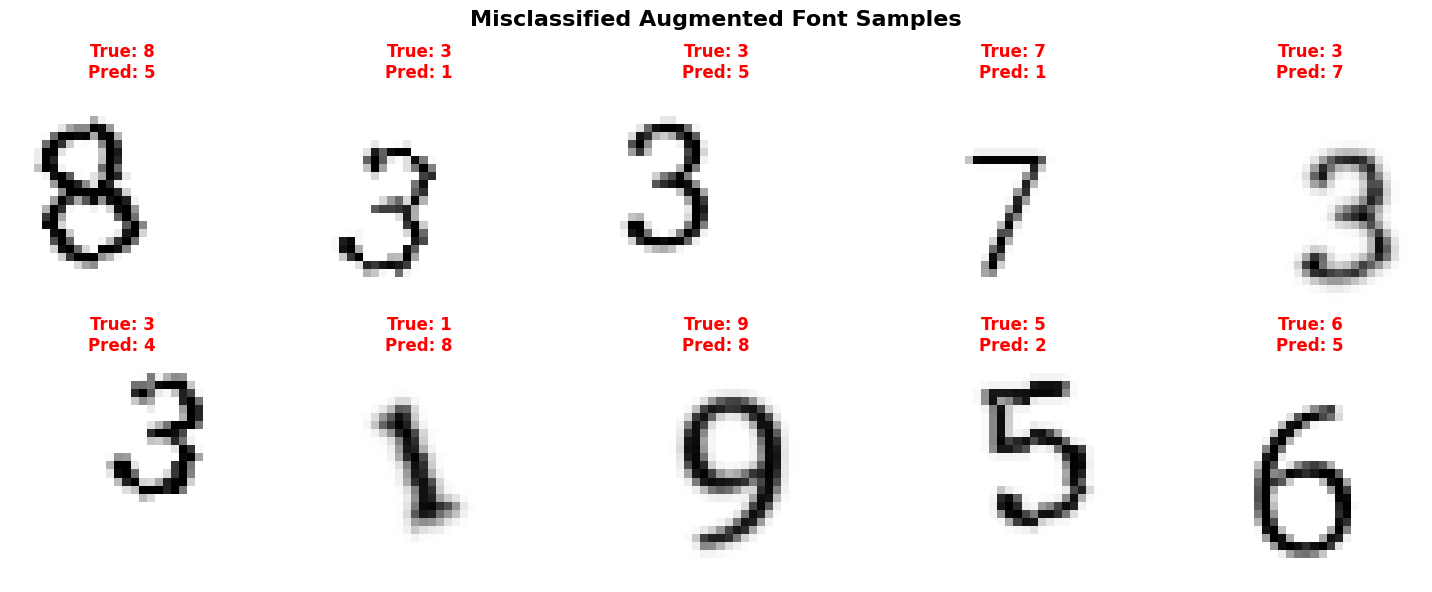

In [20]:
print("=" * 60)
print("가장 혼동된 예측")
print("=" * 60)

# 잘못 분류된 샘플 찾기
misclassified = (y_aug != y_aug_pred)
misclassified_indices = np.where(misclassified)[0]

print(f"\n전체 잘못 분류됨: {len(misclassified_indices)} / {len(y_aug)} ({len(misclassified_indices)/len(y_aug)*100:.2f}%)")

# 일부 잘못 분류된 예시 표시
if len(misclassified_indices) > 0:
    num_examples = min(10, len(misclassified_indices))
    sample_indices = np.random.choice(misclassified_indices, num_examples, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(sample_indices):
        ax = axes[idx]
        image = X_aug.iloc[sample_idx].to_numpy().reshape(28, 28)
        ax.imshow(image, cmap='binary')
        ax.axis('off')
        true_label = y_aug.iloc[sample_idx]
        pred_label = y_aug_pred[sample_idx]
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', 
                    color='red', fontweight='bold')
    
    plt.suptitle('Misclassified Augmented Font Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("잘못 분류된 샘플이 없습니다! 완벽한 정확도!")

## 7. 숫자별 분석

In [21]:
# 숫자별 정확도 분석
print("=" * 60)
print("숫자별 정확도 분석")
print("=" * 60)

for digit in range(10):
    digit_mask = (y_aug == digit)
    digit_total = digit_mask.sum()
    digit_correct = ((y_aug == digit) & (y_aug_pred == digit)).sum()
    digit_accuracy = digit_correct / digit_total if digit_total > 0 else 0
    
    print(f"숫자 {digit}: {digit_correct:4d}/{digit_total:4d} = {digit_accuracy:.4f} ({digit_accuracy*100:.2f}%)")

print("=" * 60)

숫자별 정확도 분석
숫자 0:    6/  15 = 0.4000 (40.00%)
숫자 1:    4/  15 = 0.2667 (26.67%)
숫자 2:   10/  15 = 0.6667 (66.67%)
숫자 3:    5/  15 = 0.3333 (33.33%)
숫자 4:    3/  15 = 0.2000 (20.00%)
숫자 5:   10/  15 = 0.6667 (66.67%)
숫자 6:    2/  15 = 0.1333 (13.33%)
숫자 7:    7/  15 = 0.4667 (46.67%)
숫자 8:    8/  15 = 0.5333 (53.33%)
숫자 9:    2/  15 = 0.1333 (13.33%)


## 요약

이 분석은 **표준 손글씨 MNIST 숫자**로 훈련된 모델이 다양한 변형(회전, 블러, 위치 오프셋, 폰트 크기/스타일 변형)이 적용된 **합성 폰트 기반 증강 데이터**에서 테스트할 때 어떻게 수행되는지 보여줍니다.

**주요 인사이트:**
- **정확도**는 폰트 기반 변형에 대한 모델의 전반적인 강건성을 나타냅니다
- **혼동 행렬**은 어떤 숫자 쌍이 가장 자주 혼동되는지 보여줍니다
- **잘못 분류된 예시**는 폰트 기반 특징이 모델을 혼동시키는 특정 사례를 보여줍니다
- **숫자별 정확도**는 증강으로 인해 가장 어려운 숫자를 식별합니다

이는 다음을 이해하는 데 유용합니다:
1. 폰트 변형에 대한 모델의 강건성
2. 어떤 변형이 가장 많은 혼동을 야기하는지
3. 증강된 데이터로 추가 훈련하면 일반화가 개선될지 여부
4. 향후 훈련에서 더 많은 주의가 필요한 숫자